In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# XGBoost imports
import numpy as np
from typing import Dict, Tuple
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

# Linear Regression Analysis

In [8]:
df = pd.read_csv('data/fpl_features_last4_elo.csv')

In [9]:
df = df[df["target_points_next_gw"].notna()].copy()

Y = df["target_points_next_gw"]
X = df.drop(columns=["target_points_next_gw","name", "GW","kickoff_time", "opponent_team", "total_points", "GW", "season", "gw", "position", "team", "player_id", "META_position", "META_gw", "META_is_home"])
X.sort_index()
print(X.columns)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

mae

Index(['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element',
       'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence',
       'minutes', 'own_goals', 'penalties_missed', 'penalties_saved',
       'red_cards', 'round', 'saves', 'selected', 'team_a_score',
       'team_h_score', 'threat', 'transfers_balance', 'transfers_in',
       'transfers_out', 'value', 'was_home', 'yellow_cards', 'xP',
       'expected_assists', 'expected_goal_involvements', 'expected_goals',
       'expected_goals_conceded', 'starts', 'FORM_total_points_mean_4',
       'FORM_total_points_sum_4', 'FORM_minutes_mean_4', 'FORM_minutes_sum_4',
       'FORM_goals_scored_sum_4', 'FORM_assists_sum_4', 'FORM_start_rate_4',
       'TEAM_ATT_goals_scored_mean_4', 'TEAM_DEF_goals_conceded_mean_4',
       'OPP_ATT_goals_scored_mean_4', 'OPP_DEF_goals_conceded_mean_4',
       'TEAM_elo', 'OPP_elo', 'RATE_goals_per_min', 'RATE_assists_per_min',
       'RATE_xG_per_min', 'RATE_xA_per_min', 'did_n

1.0835649576255697

MAE: 1.0835649576279716
                     Feature  Normalized_Coefficient
11                   minutes                0.649823
22         transfers_balance                0.463532
9                  ict_index                0.431202
23              transfers_in               -0.400708
24             transfers_out                0.352977
10                 influence               -0.320227
25                     value                0.255554
36       FORM_minutes_mean_4                0.218725
35   FORM_total_points_sum_4                0.173193
28                        xP                0.160743
51    did_not_play_last_game               -0.149204
40         FORM_start_rate_4               -0.145555
2                        bps                0.115473
18                  selected                0.113826
21                    threat               -0.099062
17                     saves                0.093020
15                 red_cards               -0.067747
4                 crea

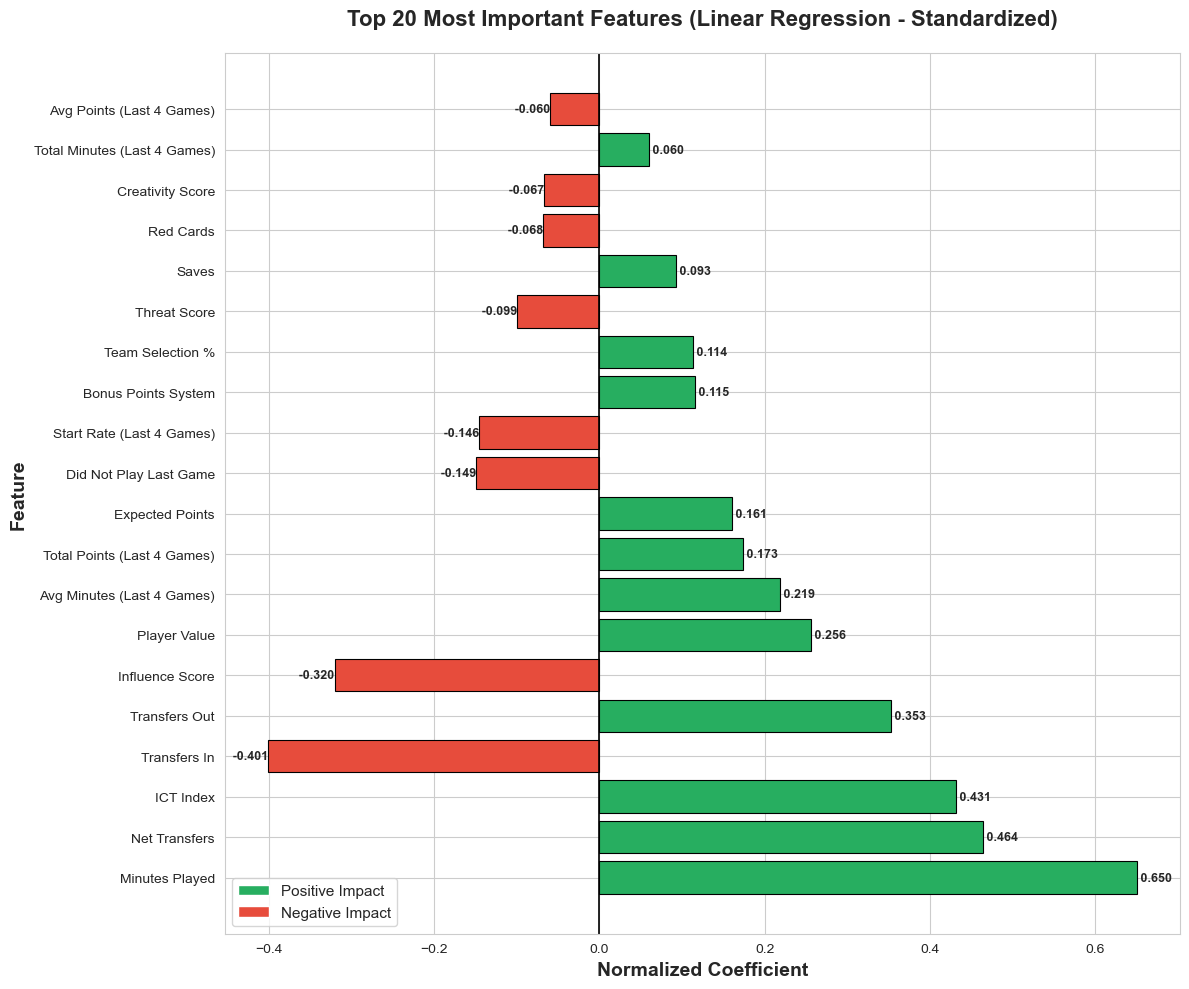

In [10]:
df = df[df["target_points_next_gw"].notna()].copy()
scaler = StandardScaler()

Y = df["target_points_next_gw"]
X = df.drop(columns=["target_points_next_gw","name", "GW","kickoff_time", "opponent_team", "total_points", "GW", "season", "gw", "position", "team", "player_id", "META_position", "META_gw", "META_is_home"])
X.sort_index()
X = X.fillna(0)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

predictions_scaled = model_scaled.predict(X_test)  # Changed from model to model_scaled
mae_scaled = mean_absolute_error(y_test, predictions_scaled)  # Changed from predictions to predictions_scaled

print(f"MAE: {mae_scaled}")

# Now get normalized feature weights
feature_weights_normalized = pd.DataFrame({
    'Feature': X.columns,
    'Normalized_Coefficient': model_scaled.coef_
}).sort_values('Normalized_Coefficient', key=abs, ascending=False)

print(feature_weights_normalized.head(20))

import seaborn as sns

# Set style for cleaner look
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

top_features = feature_weights_normalized.head(20).copy()  # Added .copy()
label_mapping = {
    'assists': 'Assists',
    'bonus': 'Bonus Points',
    'bps': 'Bonus Points System',
    'clean_sheets': 'Clean Sheets',
    'creativity': 'Creativity Score',
    'element': 'Player ID',
    'fixture': 'Fixture ID',
    'goals_conceded': 'Goals Conceded',
    'goals_scored': 'Goals Scored',
    'ict_index': 'ICT Index',
    'influence': 'Influence Score',
    'minutes': 'Minutes Played',
    'own_goals': 'Own Goals',
    'penalties_missed': 'Penalties Missed',
    'penalties_saved': 'Penalties Saved',
    'red_cards': 'Red Cards',
    'round': 'Gameweek Round',
    'saves': 'Saves',
    'selected': 'Team Selection %',
    'team_a_score': 'Away Team Score',
    'team_h_score': 'Home Team Score',
    'threat': 'Threat Score',
    'transfers_balance': 'Net Transfers',
    'transfers_in': 'Transfers In',
    'transfers_out': 'Transfers Out',
    'value': 'Player Value',
    'was_home': 'Home Game',
    'yellow_cards': 'Yellow Cards',
    'xP': 'Expected Points',
    'expected_assists': 'Expected Assists (xA)',
    'expected_goal_involvements': 'Expected Goal Involvements (xGI)',
    'expected_goals': 'Expected Goals (xG)',
    'expected_goals_conceded': 'Expected Goals Conceded (xGC)',
    'starts': 'Games Started',
    'FORM_total_points_mean_4': 'Avg Points (Last 4 Games)',
    'FORM_total_points_sum_4': 'Total Points (Last 4 Games)',
    'FORM_minutes_mean_4': 'Avg Minutes (Last 4 Games)',
    'FORM_minutes_sum_4': 'Total Minutes (Last 4 Games)',
    'FORM_goals_scored_sum_4': 'Goals (Last 4 Games)',
    'FORM_assists_sum_4': 'Assists (Last 4 Games)',
    'FORM_start_rate_4': 'Start Rate (Last 4 Games)',
    'TEAM_ATT_goals_scored_mean_4': 'Team Attack: Avg Goals',
    'TEAM_DEF_goals_conceded_mean_4': 'Team Defense: Avg Goals Conceded',
    'OPP_ATT_goals_scored_mean_4': 'Opponent Attack: Avg Goals',
    'OPP_DEF_goals_conceded_mean_4': 'Opponent Defense: Avg Goals Conceded',
    'TEAM_elo': 'Team Elo Rating',
    'OPP_elo': 'Opponent Elo Rating',
    'RATE_goals_per_min': 'Goals per Minute',
    'RATE_assists_per_min': 'Assists per Minute',
    'RATE_xG_per_min': 'xG per Minute',
    'RATE_xA_per_min': 'xA per Minute',
    'did_not_play_last_game': 'Did Not Play Last Game',
}
top_features['Feature_Label'] = top_features['Feature'].map(label_mapping).fillna(top_features['Feature'])

# Color bars based on positive/negative
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in top_features['Normalized_Coefficient']]

# Create bars with edge color for definition - CHANGED TO Feature_Label
bars = plt.barh(top_features['Feature_Label'], top_features['Normalized_Coefficient'], 
                color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    value = row['Normalized_Coefficient']
    plt.text(value, i, f' {value:.3f}', 
             va='center', ha='left' if value > 0 else 'right',
             fontweight='bold', fontsize=9)

# Styling
plt.xlabel('Normalized Coefficient', fontsize=14, fontweight='bold')
plt.ylabel('Feature', fontsize=14, fontweight='bold')
plt.title('Top 20 Most Important Features (Linear Regression - Standardized)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.2)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='Positive Impact'),
                   Patch(facecolor='#e74c3c', label='Negative Impact')]
plt.legend(handles=legend_elements, loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig('feature_weights_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# If you need to get position from the original df
test_indices = X_test.index
test_positions = df.loc[test_indices, 'position']  # or 'META_position'

# Calculate MAE by position
for position in ['FWD', 'MID', 'DEF', 'GK']:
    mask = test_positions == position
    if mask.sum() > 0:
        actual = y_test[mask]
        pred = predictions[mask]
        mae_pos = mean_absolute_error(actual, pred)
        print(f"{position}: MAE = {mae_pos:.3f} (n={mask.sum()})")

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:
lin_reg_results = {
    "Overall MAE": mae,
    "FWD MAE": 1.199,
    "MID MAE": 1.035,
    "DEF MAE": 1.125,
    "GK MAE": 0.726}

lin_reg_df = pd.DataFrame(list(lin_reg_results.items()), 
                          columns=['Position', 'Linear Regression MAE'])


In [ ]:
lin_reg_df

,Position,Linear Regression MAE
0,Overall MAE,1.083565
1,FWD MAE,1.199000
2,MID MAE,1.035000
3,DEF MAE,1.125000
4,GK MAE,0.726000


# XGBoost Modeling


In [12]:
# XGBoost Configuration
SEASONS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24"]
TRAIN_SEASONS = ["2019-20", "2020-21", "2021-22"]
VAL_SEASONS = ["2022-23"]
TEST_SEASONS = ["2023-24"]

TARGET_COL = "target_points_next_gw"

DEFAULT_XGB_PARAMS = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
}


In [13]:
# -------------------------------------------------------------------
# Dataset construction (adapted to use CSV data)
# -------------------------------------------------------------------

def get_datasets(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Build train/val/test splits from the CSV DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame loaded from CSV (already loaded in notebook as 'df')
    
    Returns
    -------
    X_train, y_train, X_val, y_val, X_test, y_test
    """
    print("\nBuilding datasets from CSV data...")
    
    # Filter out rows without target
    df = df[df[TARGET_COL].notna()].copy()
    
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in feature table")

    # ID / metadata columns (not used as features directly)
    id_cols = [
        "season",
        "gw",
        "player_id",
        "name",
        "team",
        "opponent_team",
    ]

    # Same-GW outcome / leakage columns (MUST NOT be used as features)
    leak_cols = [
        "total_points", "bonus", "bps", "goals_scored", "assists",
        "clean_sheets", "goals_conceded", "saves", "penalties_saved",
        "penalties_missed", "ict_index", "influence", "creativity", "threat",
        "red_cards", "yellow_cards", "own_goals",
        "expected_goals", "expected_assists", "expected_goal_involvements",
        "expected_goals_conceded", "selected", "transfers_in", "transfers_out",
        "transfers_balance", "value", "xP", "team_a_score", "team_h_score",
    ]

    # Feature prefixes we want to include
    feature_prefixes = [
        "FORM_",
        "TEAM_ATT_",
        "TEAM_DEF_",
        "OPP_ATT_",
        "OPP_DEF_",
        "RATE_",
        "META_",
        "PRICE_",
    ]

    # Build feature column list from the feature table
    feature_cols = []
    for col in df.columns:
        if any(col.startswith(p) for p in feature_prefixes):
            feature_cols.append(col)
        elif col in ["did_not_play_last_game", "TEAM_elo", "OPP_elo"]:
            feature_cols.append(col)

    # Remove IDs + leakage columns from the feature set
    exclude = set(id_cols + leak_cols + [TARGET_COL])
    feature_cols = sorted(list({c for c in feature_cols if c not in exclude}))

    # Sanity check: ensure META_position is present (for position models)
    if "META_position" not in feature_cols and "META_position" in df.columns:
        feature_cols.append("META_position")

    # Train / val / test masks
    train_mask = df["season"].isin(TRAIN_SEASONS)
    val_mask = df["season"].isin(VAL_SEASONS)
    test_mask = df["season"].isin(TEST_SEASONS)

    X_train = df.loc[train_mask, feature_cols].copy()
    y_train = df.loc[train_mask, TARGET_COL].copy()

    X_val = df.loc[val_mask, feature_cols].copy()
    y_val = df.loc[val_mask, TARGET_COL].copy()

    X_test = df.loc[test_mask, feature_cols].copy()
    y_test = df.loc[test_mask, TARGET_COL].copy()

    # Fill any remaining NaNs with 0
    X_train = X_train.fillna(0)
    X_val = X_val.fillna(0)
    X_test = X_test.fillna(0)

    print("\nDataset summary:")
    print(f"  Train: {len(X_train)} examples, {X_train.shape[1]} features")
    print(f"  Val:   {len(X_val)} examples, {X_val.shape[1]} features")
    print(f"  Test:  {len(X_test)} examples, {X_test.shape[1]} features")
    print("  Target: one-week-ahead FPL points (target_points_next_gw).")

    return X_train, y_train, X_val, y_val, X_test, y_test


In [14]:
# -------------------------------------------------------------------
# Model training / evaluation
# -------------------------------------------------------------------

def train_xgb_model(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    params: Dict | None = None,
) -> Tuple[XGBRegressor, float, float]:
    """
    Train an XGBRegressor model with early stopping.

    Returns
    -------
    model, val_mae, val_rmse
    """
    model_params = DEFAULT_XGB_PARAMS.copy()
    if params is not None:
        model_params.update(params)

    if "eval_metric" not in model_params:
        model_params["eval_metric"] = "mae"
    if "early_stopping_rounds" not in model_params:
        model_params["early_stopping_rounds"] = 50

    model = XGBRegressor(**model_params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    y_val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)

    return model, val_mae, val_rmse


def evaluate_on_test(model: XGBRegressor, X_test: pd.DataFrame, y_test: pd.Series) -> Tuple[float, float]:
    """Evaluate a trained model on the test set."""
    y_test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    return test_mae, test_rmse


def get_feature_importances(
    model: XGBRegressor,
    feature_names: list,
    top_n: int = 20,
) -> pd.DataFrame:
    """Return top-n feature importances."""
    importances = model.feature_importances_
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    return df_imp.sort_values("importance", ascending=False).head(top_n)


In [15]:
# -------------------------------------------------------------------
# Global model (all positions)
# -------------------------------------------------------------------

def run_global_model(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> Tuple[pd.DataFrame, XGBRegressor]:
    """
    Train a single global model on all positions.
    """
    print("\n" + "=" * 60)
    print("Global Model (All Positions)")
    print("=" * 60)

    print("Training model...")
    model, val_mae, val_rmse = train_xgb_model(X_train, y_train, X_val, y_val)
    test_mae, test_rmse = evaluate_on_test(model, X_test, y_test)

    print(f"Val MAE (points):  {val_mae:.3f}")
    print(f"Val RMSE (points): {val_rmse:.3f}")
    print(f"Test MAE (points): {test_mae:.3f}")
    print(f"Test RMSE (points): {test_rmse:.3f}")

    print("\nTop 20 feature importances:")
    print("-" * 60)
    feature_imp_df = get_feature_importances(model, X_train.columns.tolist(), top_n=20)
    print(feature_imp_df.to_string(index=False))

    results_df = pd.DataFrame([{
        "model_type": "global",
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    }])

    return results_df, model


In [16]:
# -------------------------------------------------------------------
# Position-specific models
# -------------------------------------------------------------------

def run_position_models(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> pd.DataFrame:
    """
    Train separate models for each position (GK, DEF, MID, FWD),
    using META_position in the feature matrix to subset.
    """
    print("\n" + "=" * 60)
    print("Position-Specific Models")
    print("=" * 60)

    position_map = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}
    results = []

    if "META_position" not in X_train.columns:
        print("Warning: META_position not found in features, cannot run position models")
        return pd.DataFrame()

    for position_id, position_name in position_map.items():
        print(f"\n{position_name} (position {position_id}):")
        print("-" * 60)

        train_mask = X_train["META_position"] == position_id
        val_mask = X_val["META_position"] == position_id
        test_mask = X_test["META_position"] == position_id

        X_train_pos = X_train[train_mask].copy()
        y_train_pos = y_train.loc[train_mask]
        X_val_pos = X_val[val_mask].copy()
        y_val_pos = y_val.loc[val_mask]
        X_test_pos = X_test[test_mask].copy()
        y_test_pos = y_test.loc[test_mask]

        # Drop META_position from features for the model itself
        X_train_pos = X_train_pos.drop(columns=["META_position"])
        X_val_pos = X_val_pos.drop(columns=["META_position"])
        X_test_pos = X_test_pos.drop(columns=["META_position"])

        if len(X_train_pos) == 0:
            print(f"  No training data for {position_name}, skipping...")
            continue

        print(f"  Train: {len(X_train_pos)} examples, {X_train_pos.shape[1]} features")
        print(f"  Val:   {len(X_val_pos)} examples")
        print(f"  Test:  {len(X_test_pos)} examples")

        print("  Training model...")
        model, val_mae, val_rmse = train_xgb_model(X_train_pos, y_train_pos, X_val_pos, y_val_pos)
        test_mae, test_rmse = evaluate_on_test(model, X_test_pos, y_test_pos)

        print(f"  Val MAE (points):  {val_mae:.3f}")
        print(f"  Val RMSE (points): {val_rmse:.3f}")
        print(f"  Test MAE (points): {test_mae:.3f}")
        print(f"  Test RMSE (points): {test_rmse:.3f}")

        print(f"\n  Top 10 features for {position_name}:")
        feature_imp_df = get_feature_importances(model, X_train_pos.columns.tolist(), top_n=10)
        print(feature_imp_df.to_string(index=False))

        results.append({
            "position": position_name,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "test_mae": test_mae,
            "test_rmse": test_rmse,
        })

    return pd.DataFrame(results)


In [17]:
# -------------------------------------------------------------------
# Main execution
# -------------------------------------------------------------------

print("=" * 60)
print("FPL XGBoost Modeling - Predicting Next Gameweek Points")
print("=" * 60)

# Build datasets from the CSV DataFrame (df is already loaded in cell 2)
X_train, y_train, X_val, y_val, X_test, y_test = get_datasets(df)

# Global model
global_results, global_model = run_global_model(
    X_train, y_train, X_val, y_val, X_test, y_test
)

# Position-specific models
position_results = run_position_models(
    X_train, y_train, X_val, y_val, X_test, y_test
)

# Final summary
print("\n" + "=" * 60)
print("Final Summary - Position-Specific Results")
print("=" * 60)

if len(position_results) > 0:
    print("\nPer-Position Performance:")
    print("-" * 60)
    display_cols = ["position", "val_mae", "val_rmse", "test_mae", "test_rmse"]
    display_df = position_results[display_cols].copy()

    for col in ["val_mae", "val_rmse", "test_mae", "test_rmse"]:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}")

    print(display_df.to_string(index=False))

print("\nNote:")
print("  - This is a one-week-ahead forecasting task (predicting GW t+1 from data up to GW t).")
print("  - Features use ONLY the last 4 games of player and team form, plus ELO.")
print("  - Lower MAE/RMSE (in FPL points) indicate better predictive performance.")
print("  - Per-position models show how predictability differs by position (GK/DEF/MID/FWD).")
print()


FPL XGBoost Modeling - Predicting Next Gameweek Points

Building datasets from CSV data...

Dataset summary:
  Train: 70259 examples, 21 features
  Val:   25728 examples, 21 features
  Test:  28856 examples, 21 features
  Target: one-week-ahead FPL points (target_points_next_gw).

Global Model (All Positions)
Training model...
Val MAE (points):  1.136
Val RMSE (points): 2.041
Test MAE (points): 1.064
Test RMSE (points): 2.001

Top 20 feature importances:
------------------------------------------------------------
                       feature  importance
        did_not_play_last_game    0.491753
           FORM_minutes_mean_4    0.146083
      FORM_total_points_mean_4    0.077402
       FORM_total_points_sum_4    0.032595
            RATE_goals_per_min    0.032085
            FORM_minutes_sum_4    0.025795
             FORM_start_rate_4    0.024220
                       META_gw    0.022660
          RATE_assists_per_min    0.021268
                      TEAM_elo    0.021062
TEAM_DE

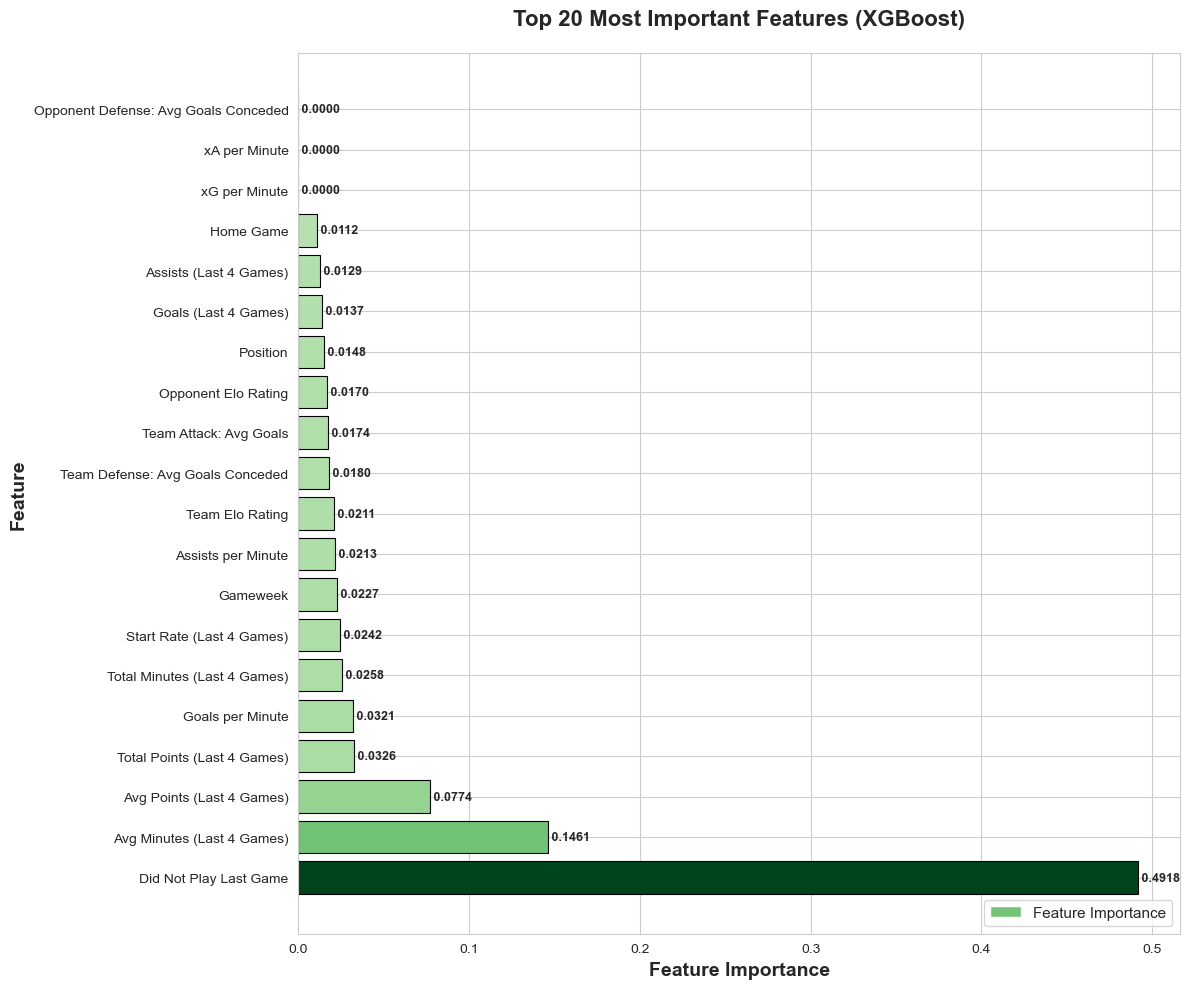

In [18]:
# XGBoost Feature Importance Visualization
import seaborn as sns

# Get feature importances from the global model
feature_imp_df = get_feature_importances(global_model, X_train.columns.tolist(), top_n=20)

# Set style for cleaner look
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

top_features = feature_imp_df.copy()

# Use the same label mapping as linear regression
label_mapping = {
    'assists': 'Assists',
    'bonus': 'Bonus Points',
    'bps': 'Bonus Points System',
    'clean_sheets': 'Clean Sheets',
    'creativity': 'Creativity Score',
    'element': 'Player ID',
    'fixture': 'Fixture ID',
    'goals_conceded': 'Goals Conceded',
    'goals_scored': 'Goals Scored',
    'ict_index': 'ICT Index',
    'influence': 'Influence Score',
    'minutes': 'Minutes Played',
    'own_goals': 'Own Goals',
    'penalties_missed': 'Penalties Missed',
    'penalties_saved': 'Penalties Saved',
    'red_cards': 'Red Cards',
    'round': 'Gameweek Round',
    'saves': 'Saves',
    'selected': 'Team Selection %',
    'team_a_score': 'Away Team Score',
    'team_h_score': 'Home Team Score',
    'threat': 'Threat Score',
    'transfers_balance': 'Net Transfers',
    'transfers_in': 'Transfers In',
    'transfers_out': 'Transfers Out',
    'value': 'Player Value',
    'was_home': 'Home Game',
    'yellow_cards': 'Yellow Cards',
    'xP': 'Expected Points',
    'expected_assists': 'Expected Assists (xA)',
    'expected_goal_involvements': 'Expected Goal Involvements (xGI)',
    'expected_goals': 'Expected Goals (xG)',
    'expected_goals_conceded': 'Expected Goals Conceded (xGC)',
    'starts': 'Games Started',
    'FORM_total_points_mean_4': 'Avg Points (Last 4 Games)',
    'FORM_total_points_sum_4': 'Total Points (Last 4 Games)',
    'FORM_minutes_mean_4': 'Avg Minutes (Last 4 Games)',
    'FORM_minutes_sum_4': 'Total Minutes (Last 4 Games)',
    'FORM_goals_scored_sum_4': 'Goals (Last 4 Games)',
    'FORM_assists_sum_4': 'Assists (Last 4 Games)',
    'FORM_start_rate_4': 'Start Rate (Last 4 Games)',
    'TEAM_ATT_goals_scored_mean_4': 'Team Attack: Avg Goals',
    'TEAM_DEF_goals_conceded_mean_4': 'Team Defense: Avg Goals Conceded',
    'OPP_ATT_goals_scored_mean_4': 'Opponent Attack: Avg Goals',
    'OPP_DEF_goals_conceded_mean_4': 'Opponent Defense: Avg Goals Conceded',
    'TEAM_elo': 'Team Elo Rating',
    'OPP_elo': 'Opponent Elo Rating',
    'RATE_goals_per_min': 'Goals per Minute',
    'RATE_assists_per_min': 'Assists per Minute',
    'RATE_xG_per_min': 'xG per Minute',
    'RATE_xA_per_min': 'xA per Minute',
    'did_not_play_last_game': 'Did Not Play Last Game',
    'META_position': 'Position',
    'META_gw': 'Gameweek',
    'META_is_home': 'Home Game',
}

top_features['Feature_Label'] = top_features['feature'].map(label_mapping).fillna(top_features['feature'])

# Use a gradient color scheme (green shades) since all importances are positive
# Normalize importances for color intensity
max_imp = top_features['importance'].max()
colors = [plt.cm.Greens(0.3 + 0.7 * (imp / max_imp)) for imp in top_features['importance']]

# Create horizontal bar chart
bars = plt.barh(top_features['Feature_Label'], top_features['importance'], 
                color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    value = row['importance']
    plt.text(value, i, f' {value:.4f}', 
             va='center', ha='left',
             fontweight='bold', fontsize=9)

# Styling
plt.xlabel('Feature Importance', fontsize=14, fontweight='bold')
plt.ylabel('Feature', fontsize=14, fontweight='bold')
plt.title('Top 20 Most Important Features (XGBoost)', 
          fontsize=16, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=plt.cm.Greens(0.5), label='Feature Importance')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('feature_weights_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()
